In [25]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
import scipy

from astropy.table import Table
from astroquery.gaia import Gaia

import sys, os, tqdm, glob
wdmodels_dir = os.environ['WDMODELS_DIR']
sys.path.append(wdmodels_dir)
import WD_models

plt.style.use("stefan.mplstyle")
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage[T1]{fontenc}\usepackage{lmodern}\usepackage{amsmath}",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

In [26]:
def mass_from_loggteff(loggarray : np.array, teffarray : np.array, 
                       low_model = 'be', mid_model = 'be', high_model = 'be',
                       atm_type = 'H') -> np.array:
    """compute the radial velocity from radius and effective temperature
    """
    mass_sun, radius_sun, newton_G, speed_light = 1.9884e30, 6.957e8, 6.674e-11, 299792458
    font_model = WD_models.load_model(low_model, mid_model, high_model, atm_type) 
    g_acc = (10**font_model['logg'])/100
    rsun = np.sqrt(font_model['mass_array'] * mass_sun * newton_G / g_acc) / radius_sun
    rad_teff_to_mass = WD_models.interp_xy_z_func(x = font_model['logg'], y = 10**font_model['logteff'],\
                                                z = font_model['mass_array'], interp_type = 'linear')
    return rad_teff_to_mass(loggarray, teffarray)

In [27]:
data_ages = pd.read_parquet("../omnidwarf/data/ages_widebinary.pqt").reset_index()
data_ages["mass"] = np.nan

data_ages.loc[:, "mass"] = mass_from_loggteff(
    data_ages.loc[:, "logg"].to_numpy(),
    data_ages.loc[:, "teff"].to_numpy(),
    atm_type="H"
)
data_ages = data_ages.query("mass > 0.63")

data_ages["v_ra"] = 4.71*data_ages["pmRA"]/data_ages["Plx"]
data_ages["v_de"] = 4.71*data_ages["pmDE"]/data_ages["Plx"]
data_ages["v_transverse"] = np.sqrt(data_ages["v_ra"]**2 + data_ages["v_de"]**2)

In [39]:
""" cross-match against Gaia
"""
QUERY = f"""select gaia.source_id as ms_source_id, gaia.radial_velocity, gaia.radial_velocity_error
        from gaiadr3.gaia_source as gaia
        where gaia.source_id in {tuple(data_ages.ms_source_id)}
        and radial_velocity is not NULL
        """
gaia_table = Gaia.launch_job_async(QUERY).get_results().to_pandas()
full_table = pd.merge(data_ages, gaia_table, on="ms_source_id")

INFO: Query finished. [astroquery.utils.tap.core]


In [55]:
import astropy.units as u
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord, Galactocentric

def gaia_to_galactocentric_vxyz(
    ra_deg, dec_deg, parallax_mas, pmra_masyr, pmdec_masyr, rv_kms,
    *,
    galcen_distance=8.122*u.kpc,
    z_sun=20.8*u.pc,
    roll=0*u.deg,
    galcen_v_sun=(12.9, 245.6, 7.78) * u.km/u.s,
    frame_defaults="v4.0",
):

    c_icrs = SkyCoord(
        ra=ra_deg * u.degree,
        dec=dec_deg * u.degree,
        distance=1000/parallax_mas * u.pc,
        pm_ra_cosdec=pmra_masyr * u.mas/u.yr,
        pm_dec=pmdec_masyr * u.mas/u.yr,
        radial_velocity=rv_kms * u.km/u.second,
        frame="icrs",
    )

    c_gc = c_icrs.transform_to(coord.Galactocentric())

    # Cartesian velocities in the Galactocentric frame
    vx = c_gc.v_x.to(u.km/u.s)
    vy = c_gc.v_y.to(u.km/u.s)
    vz = c_gc.v_z.to(u.km/u.s)

    # Positions too, if you want them:
    x = c_gc.x.to(u.kpc)
    y = c_gc.y.to(u.kpc)
    z = c_gc.z.to(u.kpc)

    return x, y, z, vx, vy, vz

pos = gaia_to_galactocentric_vxyz(
    full_table["ms_ra"].to_numpy(), full_table["ms_dec"].to_numpy(), full_table["ms_parallax"].to_numpy(),
    full_table["ms_pmra"].to_numpy(), full_table["ms_pmdec"].to_numpy(), full_table["radial_velocity"].to_numpy()
)
full_table["gal_X"] = pos[0].value ; full_table["gal_vX"] = pos[3].value
full_table["gal_Y"] = pos[1].value ; full_table["gal_vY"] = pos[4].value
full_table["gal_Z"] = pos[2].value ; full_table["gal_vZ"] = pos[5].value

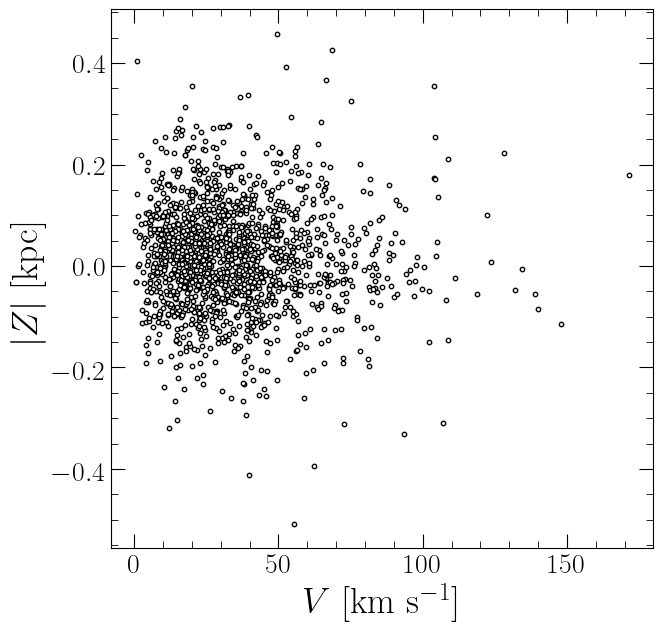

In [69]:
V_LSR = 232
Vmax = 210

fig, ax = plt.subplots()

ax.scatter(
    full_table["v_transverse"],
    full_table["gal_Z"],
    c="white", edgecolor="k", s=10
)

# Add the |V - V_LSR| < 210 circle
circle = plt.Circle(
    (V_LSR, 0),
    Vmax,
    facecolor="none",
    edgecolor="red",
    lw=2
)


ax.set_xlabel(r"$V$ [km s$^{-1}$]")
ax.set_ylabel(r"$|Z|$ [kpc]")
plt.show()